In [48]:
import geopandas as gpd
import osmnx as ox

import pandas as pd
sal= pd.read_csv('../pop_pred_final.csv')
phm=pd.read_csv('../../PHARMACIES_places_full_results.csv')

In [22]:
salpoint=gpd.read_file('../../2011_census/2011_Census/2011_ea_sal_centroids_kzn_gp.dbf')
salpoly=gpd.read_file('../../2011_census/2011_Census/ea_sal_kzn_gp.dbf')


In [5]:
#kznwalk=ox.load_graphml('../../networks/network_kwazulu_natal_walk.graphml')
# kzndrive=ox.load_graphml('../../networks/network_kwazulu_natal_drive.graphml')
# gauwalk=ox.load_graphml('../../networks/network_gauteng_walk.graphml')
# gaudrive=ox.load_graphml('../../networks/network_gauteng_drive.graphml')

In [23]:
pharm_gdf = gpd.GeoDataFrame(
    phm,
    geometry=gpd.points_from_xy(phm['lng'], phm['lat']),
    crs="EPSG:4326"  # WGS84
)
pharm_gdf = pharm_gdf.to_crs(salpoly.crs)

In [24]:
pharm_with_sal = gpd.sjoin(
    pharm_gdf,
    salpoly[['EA_CODE', 'EA_GTYPE', 'geometry']],
    how='left',
    predicate='within'
)

In [49]:
sal = sal.merge(
    salpoint[["EA_CODE", "PR_NAME", 'geometry']],
    on="EA_CODE",
    how="left"
)
sal = gpd.GeoDataFrame(sal, geometry="geometry")

C:\Users\kalmanj\AppData\Local\Temp\ipykernel_31500\3307617542.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  sal = sal.merge(


In [276]:
# def assign_catchment(row):
#     if row['EA_GTYPE'] == 'Urban':
#         return 0.5 * 1609.34
#     elif row['EA_GTYPE'] == 'Traditional':
#         return 5 * 1609.34
#     else:
#         return 15 *1609.34

# sal['catchment'] = sal.apply(assign_catchment, axis=1)
# pharm_with_sal['catchment'] =5 * 1609.34

In [34]:
pharm_with_sal = pharm_with_sal[
    pharm_with_sal.geometry.x.notna() &
    pharm_with_sal.geometry.y.notna()
]

In [50]:
kznsal = sal[sal["PR_NAME"] == "KwaZulu-Natal"].copy()
gausal = sal[sal["PR_NAME"] == "Gauteng"].copy()

In [51]:
kznpharm= pharm_with_sal[pharm_with_sal["PROVINCE"] == "KwaZulu-Natal"].copy()
gaupharm = pharm_with_sal[pharm_with_sal["PROVINCE"] == "Gauteng"].copy()

In [156]:
kznwalk = ox.project_graph(kznwalk)
kznwalk.graph["crs"]

<Projected CRS: EPSG:32661>
Name: WGS 84 / UPS North (N,E)
Axis Info [cartesian]:
- N[south]: Northing (metre)
- E[south]: Easting (metre)
Area of Use:
- name: Northern hemisphere - north of 60°N onshore and offshore, including Arctic.
- bounds: (-180.0, 60.0, 180.0, 90.0)
Coordinate Operation:
- name: Universal Polar Stereographic North
- method: Polar Stereographic (variant A)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
###KZN (URBAN AND RURAL)

In [157]:
import osmnx as ox
import networkx as nx
from tqdm import tqdm


kznsal = kznsal.to_crs(kznwalk.graph["crs"])
kznpharm = kznpharm.to_crs(kznwalk.graph["crs"])


In [158]:

# ----------------------------
# GRAPH TRUNCATION
(maxy, miny, maxx, minx) = kznsal.total_bounds 
bbox = (maxy, miny, maxx, minx)

kznwalk = ox.truncate.truncate_graph_bbox(kznwalk, bbox)

In [159]:

# ----------------------------
# NODE ASSIGNMENT
# ----------------------------
kznsal["node"] = ox.nearest_nodes(
    kznwalk,
    kznsal.geometry.x,
    kznsal.geometry.y
)

pharm_gdf = kznpharm.copy()
pharm_gdf = pharm_gdf[
    pharm_gdf.geometry.x.notna() &
    pharm_gdf.geometry.y.notna()
]
pharm_gdf = pharm_gdf[~pharm_gdf.geometry.is_empty]

pharm_gdf["node"] = ox.nearest_nodes(
    kznwalk,
    pharm_gdf.geometry.x,
    pharm_gdf.geometry.y
)



In [160]:
# ----------------------------
# STEP 1: Rj (SUPPLY SIDE)
# ----------------------------
Rj_list = []

for idx, pharm in tqdm(pharm_gdf.iterrows(), total=len(pharm_gdf)):

    lengths = nx.single_source_dijkstra_path_length(
        kznwalk,
        pharm["node"],
        cutoff=8046, #equal m per pharm (5miles)
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pop = kznsal[kznsal["node"].isin(reachable_nodes)]

    total_pop = nearby_pop["sal2023_est"].sum()

    Rj = 5000 / total_pop if total_pop > 0 else 0  #we have to assume equal supply at pharm rn. doing 1000 as an ode to pharmacies per 1000 pe0ple 

    Rj_list.append(Rj)

pharm_gdf = pharm_gdf.reset_index(drop=True)
pharm_gdf["Rj"] = Rj_list
# ----------------------------
# STEP 2: Ai (DEMAND SIDE)
# ----------------------------
Ai_list = []

for idx, pop in tqdm(kznsal.iterrows(), total=len(kznsal)):

    lengths = nx.single_source_dijkstra_path_length(
        kznwalk,
        pop["node"],
        cutoff=1609.34, #since this is the walking graph, doing 1 mile for every sal (1609m)   
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pharm = pharm_gdf[pharm_gdf["node"].isin(reachable_nodes)]

    Ai = nearby_pharm["Rj"].sum()

    Ai_list.append(Ai)

kznsal["Ai_walk"] = Ai_list

100%|██████████████████████████████████████████████████████████████████████████| 15539/15539 [00:15<00:00, 1007.11it/s]


In [161]:
kznsal["Ai_walk"].describe()

count    15539.000000
mean         0.081338
std          0.315839
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.979662
Name: Ai_walk, dtype: float64

In [ ]:
##THe higher the ai the better. this one is highly skewed because KZN is highly rural so >90 of Ai will be 0

In [75]:
kzndrive=ox.load_graphml('../../networks/network_kwazulu_natal_drive.graphml')


In [163]:
kzndrive = ox.project_graph(kzndrive)
kznsal = kznsal.to_crs(kzndrive.graph["crs"])
kznpharm = kznpharm.to_crs(kzndrive.graph["crs"])

In [164]:
# ----------------------------
# GRAPH TRUNCATION
(maxy, miny, maxx, minx) = kznsal.total_bounds 
bbox = (maxy, miny, maxx, minx)

kzndrive = ox.truncate.truncate_graph_bbox(kzndrive, bbox)

In [165]:

# ----------------------------
# NODE ASSIGNMENT
# ----------------------------
kznsal["node"] = ox.nearest_nodes(
    kzndrive,
    kznsal.geometry.x,
    kznsal.geometry.y
)

pharm_gdf = kznpharm.copy()
pharm_gdf = pharm_gdf[
    pharm_gdf.geometry.x.notna() &
    pharm_gdf.geometry.y.notna()
]
pharm_gdf = pharm_gdf[~pharm_gdf.geometry.is_empty]

pharm_gdf["node"] = ox.nearest_nodes(
    kzndrive,
    pharm_gdf.geometry.x,
    pharm_gdf.geometry.y
)


In [166]:
# ----------------------------
# STEP 1: Rj (SUPPLY SIDE)
# ----------------------------
Rj_list = []

for idx, pharm in tqdm(pharm_gdf.iterrows(), total=len(pharm_gdf)):

    lengths = nx.single_source_dijkstra_path_length(
        kzndrive,
        pharm["node"],
        cutoff=8046, #equal m per pharm (5miles)
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pop = kznsal[kznsal["node"].isin(reachable_nodes)]

    total_pop = nearby_pop["sal2023_est"].sum()

    Rj = 5000 / total_pop if total_pop > 0 else 0  #we have to assume equal supply at pharm rn. 
    Rj_list.append(Rj)

pharm_gdf = pharm_gdf.reset_index(drop=True)
pharm_gdf["Rj"] = Rj_list
# ----------------------------
# STEP 2: Ai (DEMAND SIDE)
# ----------------------------
Ai_list = []

for idx, pop in tqdm(kznsal.iterrows(), total=len(kznsal)):

    lengths = nx.single_source_dijkstra_path_length(
        kzndrive,
        pop["node"],
        cutoff=8045, #drive 5 miles
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pharm = pharm_gdf[pharm_gdf["node"].isin(reachable_nodes)]

    Ai = nearby_pharm["Rj"].sum()

    Ai_list.append(Ai)

kznsal["Ai_drive"] = Ai_list

100%|███████████████████████████████████████████████████████████████████████████| 15539/15539 [02:27<00:00, 105.09it/s]


In [167]:
kznsal["Ai_drive"].describe()

count    15539.000000
mean         0.899933
std          1.979431
min          0.000000
25%          0.000000
50%          0.172299
75%          1.306116
max        168.618728
Name: Ai_drive, dtype: float64

<Axes: >

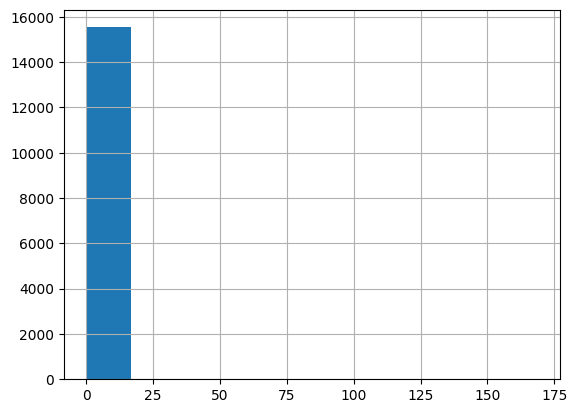

In [168]:
kznsal["Ai_drive"].hist()

In [90]:
gauwalk=ox.load_graphml('../../networks/network_gauteng_walk.graphml')
gauwalk = ox.project_graph(gauwalk)
gauwalk.graph["crs"]

<Projected CRS: EPSG:32735>
Name: WGS 84 / UTM zone 35S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 24°E and 30°E, southern hemisphere between 80°S and equator, onshore and offshore. Botswana. Burundi. Democratic Republic of the Congo (Zaire). Rwanda. South Africa. Tanzania. Uganda. Zambia. Zimbabwe.
- bounds: (24.0, -80.0, 30.0, 0.0)
Coordinate Operation:
- name: UTM zone 35S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [91]:
gausal = gausal.to_crs(gauwalk.graph["crs"])
gaupharm = gaupharm.to_crs(gauwalk.graph["crs"])

In [169]:

# ----------------------------
# GRAPH TRUNCATION
(maxy, miny, maxx, minx) = gausal.total_bounds 
bbox = (maxy, miny, maxx, minx)

gauwalk = ox.truncate.truncate_graph_bbox(gauwalk, bbox)

In [170]:

# ----------------------------
# NODE ASSIGNMENT
# ----------------------------
gausal["node"] = ox.nearest_nodes(
    gauwalk,
    gausal.geometry.x,
    gausal.geometry.y
)

pharm_gdf = gaupharm.copy()
pharm_gdf = pharm_gdf[
    pharm_gdf.geometry.x.notna() &
    pharm_gdf.geometry.y.notna()
]
pharm_gdf = pharm_gdf[~pharm_gdf.geometry.is_empty]

pharm_gdf["node"] = ox.nearest_nodes(
    gauwalk,
    pharm_gdf.geometry.x,
    pharm_gdf.geometry.y
)



In [171]:
# ----------------------------
# STEP 1: Rj (SUPPLY SIDE)
# ----------------------------
Rj_list = []

for idx, pharm in tqdm(pharm_gdf.iterrows(), total=len(pharm_gdf)):

    lengths = nx.single_source_dijkstra_path_length(
        gauwalk,
        pharm["node"],
        cutoff=4023, #equal m per pharm (2.5miles)
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pop = gausal[gausal["node"].isin(reachable_nodes)]

    total_pop = nearby_pop["sal2023_est"].sum()

    Rj = 10000 / total_pop if total_pop > 0 else 0  #we have to assume equal supply at pharm rn. doing 1000 to avoid miniscule 0s

    Rj_list.append(Rj)

pharm_gdf = pharm_gdf.reset_index(drop=True)
pharm_gdf["Rj"] = Rj_list
# ----------------------------
# STEP 2: Ai (DEMAND SIDE)
# ----------------------------
Ai_list = []

for idx, pop in tqdm(gausal.iterrows(), total=len(gausal)):

    lengths = nx.single_source_dijkstra_path_length(
        gauwalk,
        pop["node"],
        cutoff=1609.34, #since this is the walking graph, doing 1 mile for every sal (1609m)   
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pharm = pharm_gdf[pharm_gdf["node"].isin(reachable_nodes)]

    Ai = nearby_pharm["Rj"].sum()

    Ai_list.append(Ai)

gausal["Ai_walk"] = Ai_list

100%|███████████████████████████████████████████████████████████████████████████| 18528/18528 [00:42<00:00, 440.66it/s]


In [172]:
gausal["Ai_walk"].describe() 

count    18528.000000
mean         0.802605
std         15.369407
min          0.000000
25%          0.000000
50%          0.000000
75%          0.599142
max       1960.157551
Name: Ai_walk, dtype: float64

<Axes: >

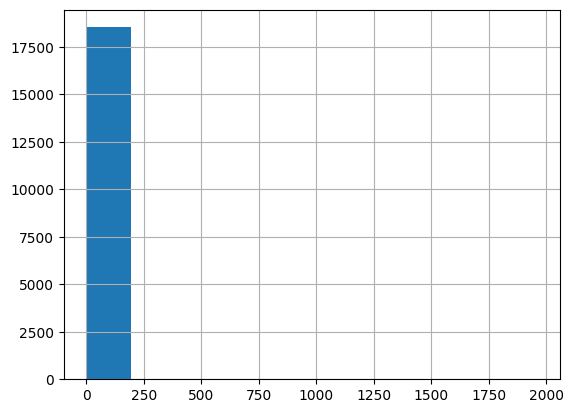

In [173]:
gausal["Ai_walk"].hist() 

In [97]:
gaudrive=ox.load_graphml('../../networks/network_gauteng_drive.graphml')
gaudrive = ox.project_graph(gaudrive)
gaudrive.graph["crs"]

<Projected CRS: EPSG:32735>
Name: WGS 84 / UTM zone 35S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 24°E and 30°E, southern hemisphere between 80°S and equator, onshore and offshore. Botswana. Burundi. Democratic Republic of the Congo (Zaire). Rwanda. South Africa. Tanzania. Uganda. Zambia. Zimbabwe.
- bounds: (24.0, -80.0, 30.0, 0.0)
Coordinate Operation:
- name: UTM zone 35S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [98]:

gausal = gausal.to_crs(gaudrive.graph["crs"])
gaupharm = gaupharm.to_crs(gaudrive.graph["crs"])

In [175]:

# ----------------------------
# GRAPH TRUNCATION
(maxy, miny, maxx, minx) = gausal.total_bounds 
bbox = (maxy, miny, maxx, minx)

gaudrive = ox.truncate.truncate_graph_bbox(gaudrive, bbox)

In [176]:

# ----------------------------
# NODE ASSIGNMENT
# ----------------------------
gausal["node"] = ox.nearest_nodes(
    gaudrive,
    gausal.geometry.x,
    gausal.geometry.y
)

pharm_gdf = gaupharm.copy()
pharm_gdf = pharm_gdf[
    pharm_gdf.geometry.x.notna() &
    pharm_gdf.geometry.y.notna()
]
pharm_gdf = pharm_gdf[~pharm_gdf.geometry.is_empty]

pharm_gdf["node"] = ox.nearest_nodes(
    gaudrive,
    pharm_gdf.geometry.x,
    pharm_gdf.geometry.y
)



In [177]:
# ----------------------------
# STEP 1: Rj (SUPPLY SIDE)
# ----------------------------
Rj_list = []

for idx, pharm in tqdm(pharm_gdf.iterrows(), total=len(pharm_gdf)):

    lengths = nx.single_source_dijkstra_path_length(
        gaudrive,
        pharm["node"],
        cutoff=4023, #equal m per pharm (5miles)
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pop = gausal[gausal["node"].isin(reachable_nodes)]

    total_pop = nearby_pop["sal2023_est"].sum()

    Rj = 10000 / total_pop if total_pop > 0 else 0  #we have to assume equal supply at pharm rn. doing 1000 to avoid miniscule 0s

    Rj_list.append(Rj)

pharm_gdf = pharm_gdf.reset_index(drop=True)
pharm_gdf["Rj"] = Rj_list
# ----------------------------
# STEP 2: Ai (DEMAND SIDE)
# ----------------------------
Ai_list = []

for idx, pop in tqdm(gausal.iterrows(), total=len(gausal)):

    lengths = nx.single_source_dijkstra_path_length(
        gaudrive,
        pop["node"],
        cutoff=8046, 
        weight="length"
    )

    reachable_nodes = set(lengths.keys())

    nearby_pharm = pharm_gdf[pharm_gdf["node"].isin(reachable_nodes)]

    Ai = nearby_pharm["Rj"].sum()

    Ai_list.append(Ai)

gausal["Ai_drive"] = Ai_list

100%|████████████████████████████████████████████████████████████████████████████| 18528/18528 [07:58<00:00, 38.72it/s]


In [178]:
gausal["Ai_drive"].describe() 

count    18528.000000
mean        31.230821
std         73.559773
min          0.000000
25%          1.581367
50%          7.979087
75%         30.637219
max       1960.157551
Name: Ai_drive, dtype: float64

<Axes: >

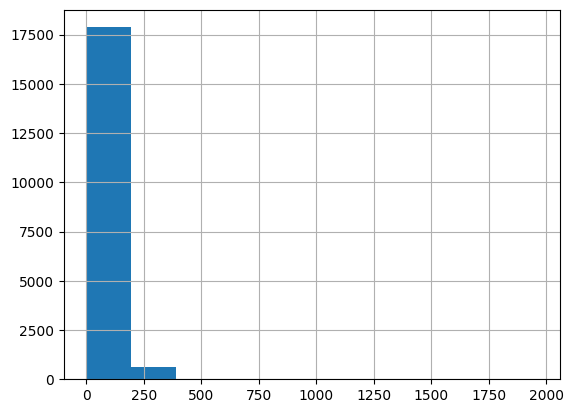

In [179]:
gausal["Ai_drive"].hist() 

In [115]:

# gausal["Ai_drive_test"] = gausal["Ai_drive"] /gausal.groupby('WardID')['Ai_drive'].transform('sum')
# gausal["Ai_walk_test"] = gausal["Ai_walk"] /gausal.groupby('WardID')['Ai_walk'].transform('sum')
# kznsal["Ai_drive_test"] = kznsal["Ai_drive"] /kznsal.groupby('WardID')['Ai_drive'].transform('sum')
# kznsal["Ai_walk_test"] = kznsal["Ai_walk"] /kznsal.groupby('WardID')['Ai_walk'].transform('sum')

In [116]:
gausal["Ai_drive_test"].describe()

count    18440.000000
mean         0.028362
std          0.031952
min          0.000000
25%          0.015132
50%          0.022209
75%          0.032696
max          1.000000
Name: Ai_drive_test, dtype: float64

In [119]:
gausal["Ai_walk_test"].describe()

count    15144.000000
mean         0.026149
std          0.054085
min          0.000000
25%          0.000000
50%          0.011416
75%          0.036134
max          1.000000
Name: Ai_walk_test, dtype: float64

In [117]:
kznsal["Ai_walk_test"].describe()

count    7157.000000
mean        0.037166
std         0.094783
min         0.000000
25%         0.000000
50%         0.000000
75%         0.035842
max         1.000000
Name: Ai_walk_test, dtype: float64

In [118]:
kznsal["Ai_drive_test"].describe()

count    10663.000000
mean         0.047641
std          0.080600
min          0.000000
25%          0.012914
50%          0.026724
75%          0.058824
max          1.000000
Name: Ai_drive_test, dtype: float64

In [200]:
kznsal = kznsal.to_crs("EPSG:32735")  # UTM zone 35S
gausal = gausal.to_crs("EPSG:32735")


allaccess = pd.concat([kznsal, gausal], ignore_index=True)
allaccess = allaccess.drop(columns='geometry')

allaccess = salpoly.merge(allaccess, on='EA_CODE', how='left')
cols = ['Ai_walk', 'Ai_drive' ]

allaccess[cols] = allaccess[cols].fillna(0)

C:\Users\kalmanj\AppData\Local\Temp\ipykernel_31500\1549509868.py:8: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  allaccess = salpoly.merge(allaccess, on='EA_CODE', how='left')


In [201]:
pharm_with_sal = pharm_with_sal.to_crs(allaccess.crs)

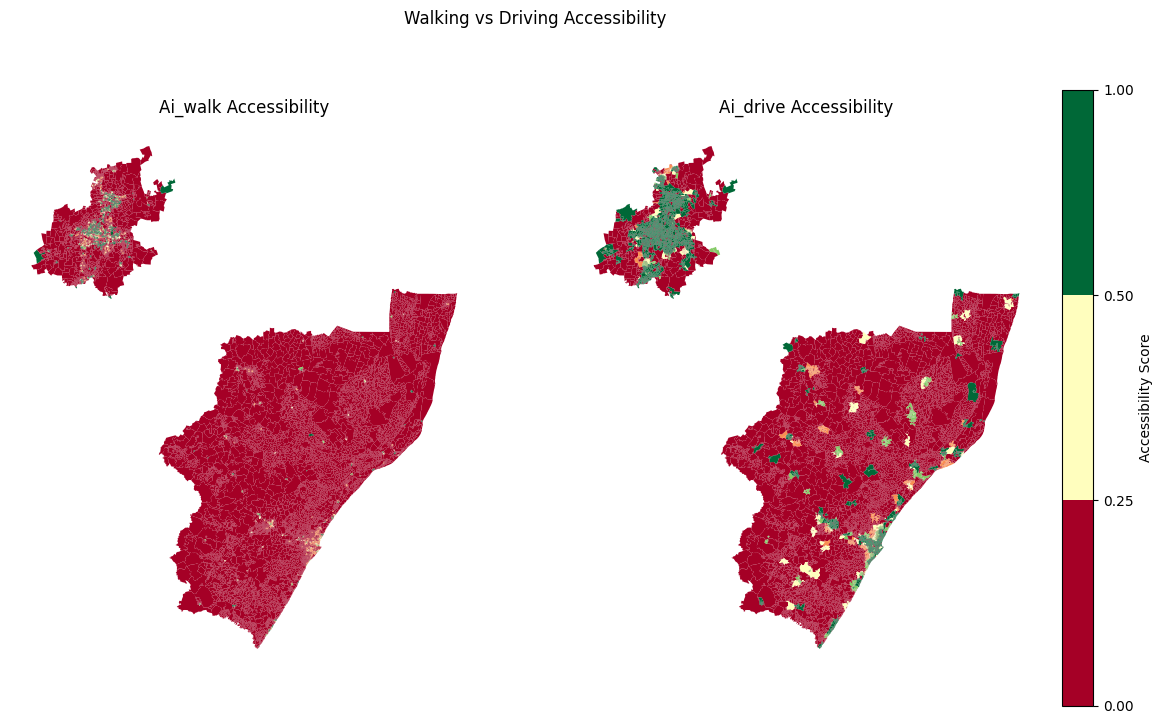

In [196]:
import matplotlib.pyplot as plt
import matplotlib as mpl

cols = ['Ai_walk', 'Ai_drive']

# shared bins (VERY important)
bin_edges = [0, 0.25, 0.5, 1]

fig, axes = plt.subplots(1, 2, figsize=(14,8))

cmap = mpl.cm.RdYlGn

for i, col in enumerate(cols):

    allaccess.plot(
        column=col,
        cmap=cmap,
        scheme='UserDefined',
        classification_kwds={'bins': bin_edges},
        legend=False,
        ax=axes[i],
        edgecolor="none"
    )

    axes[i].set_title(f"{col.capitalize()} Accessibility")
    axes[i].axis('off')

# shared colorbar
norm = mpl.colors.BoundaryNorm(bin_edges, ncolors=cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Accessibility Score")

plt.suptitle("Walking vs Driving Accessibility")

plt.savefig("walk_vs_drive.png", dpi=150, bbox_inches='tight')
plt.show()

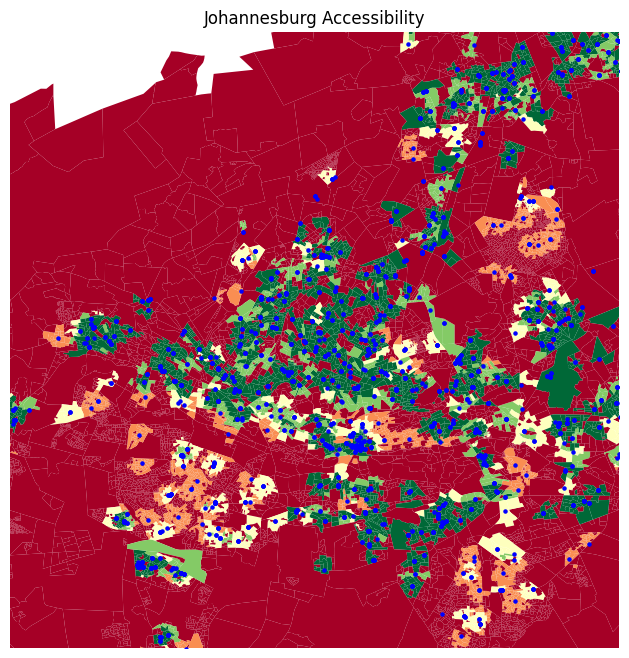

In [217]:
fig, ax = plt.subplots(figsize=(8,8))
bin_edges = [0, 0.2, 0.5, 1]
allaccess.plot(column='Ai_walk', cmap='RdYlGn', 
               scheme='UserDefined',
        classification_kwds={'bins': bin_edges},
               ax=ax)

# Johannesburg bounding box (approx)
ax.set_xlim(27.7, 28.3)
ax.set_ylim(-26.4, -25.8)
pharm_with_sal.plot(
    ax=ax,
    color='blue',
    markersize=5
)
ax.set_title("Johannesburg Accessibility")
ax.axis('off')
plt.savefig("joburg_walk_with_phms.png", dpi=150, bbox_inches='tight')

plt.show()

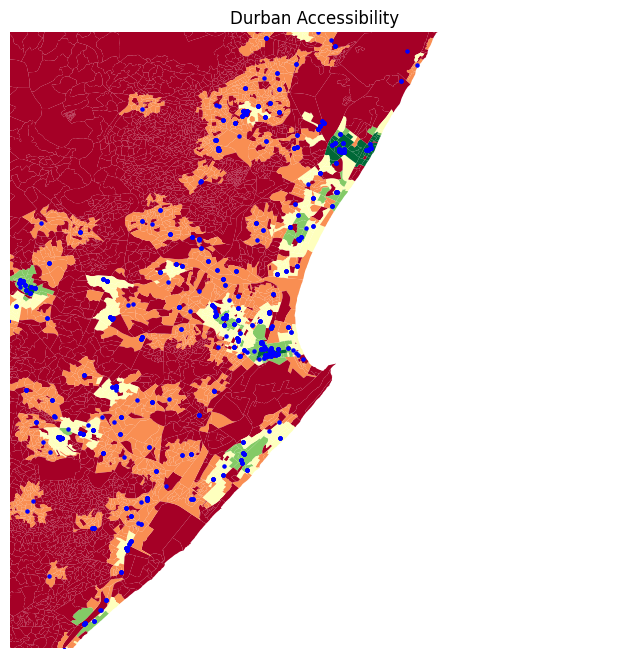

In [218]:
fig, ax = plt.subplots(figsize=(8,8))

bin_edges = [0, 0.2, 0.5, 1]

allaccess.plot(
    column='Ai_walk',
    cmap='RdYlGn',
    scheme='UserDefined',
    classification_kwds={'bins': bin_edges},
    ax=ax
)

ax.set_xlim(30.85, 31.25)
ax.set_ylim(-30.05, -29.65)

pharm_with_sal = pharm_with_sal.to_crs(allaccess.crs)

pharm_with_sal.plot(
    ax=ax,
    color='blue',
    markersize=5
)

ax.set_title("Durban Accessibility")
ax.axis('off')
plt.savefig("durban_walk_with_phms.png", dpi=150, bbox_inches='tight')

plt.show()

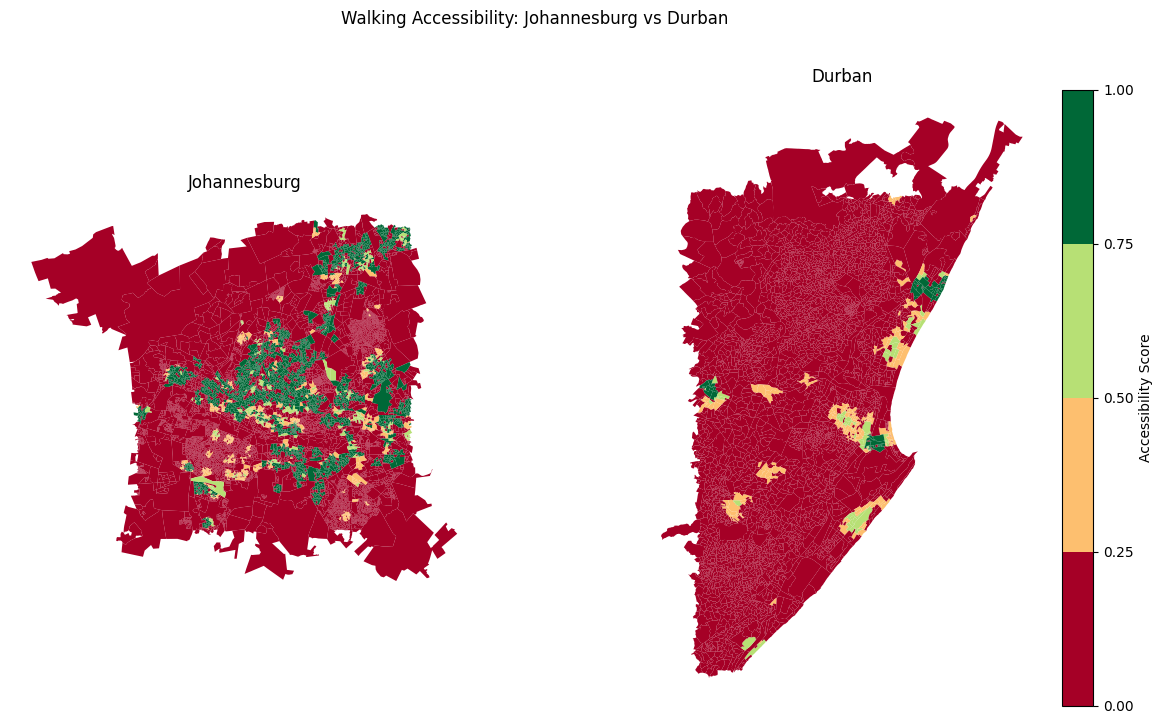

In [219]:
import matplotlib.pyplot as plt
import matplotlib as mpl

bin_edges = [0, 0.25, 0.5, 0.75,1]
cmap = mpl.cm.RdYlGn

norm = mpl.colors.BoundaryNorm(bin_edges, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

cities = {
    "Johannesburg": (27.7, 28.3, -26.4, -25.8),
    "Durban": (30.85, 31.25, -30.05, -29.65)
}

for i, (name, (xmin, xmax, ymin, ymax)) in enumerate(cities.items()):

    gdf = allaccess.cx[xmin:xmax, ymin:ymax]

    gdf.plot(
        column='Ai_walk',
        cmap=cmap,
        norm=norm,          # 🔥 THIS IS THE KEY FIX
        ax=axes[i],
        edgecolor='none'
    )

    # pharm_with_sal.cx[xmin:xmax, ymin:ymax].plot(
    #     ax=axes[i],
    #     color='#3B0C87',
    #     markersize= 1,
    #     zorder=10
    # )

    axes[i].set_title(name)
    axes[i].axis('off')

# shared colorbar (now matches exactly)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Accessibility Score")

plt.suptitle("Walking Accessibility: Johannesburg vs Durban")
plt.savefig("joburgandDurban_walking.png", dpi=150, bbox_inches='tight')

plt.show()

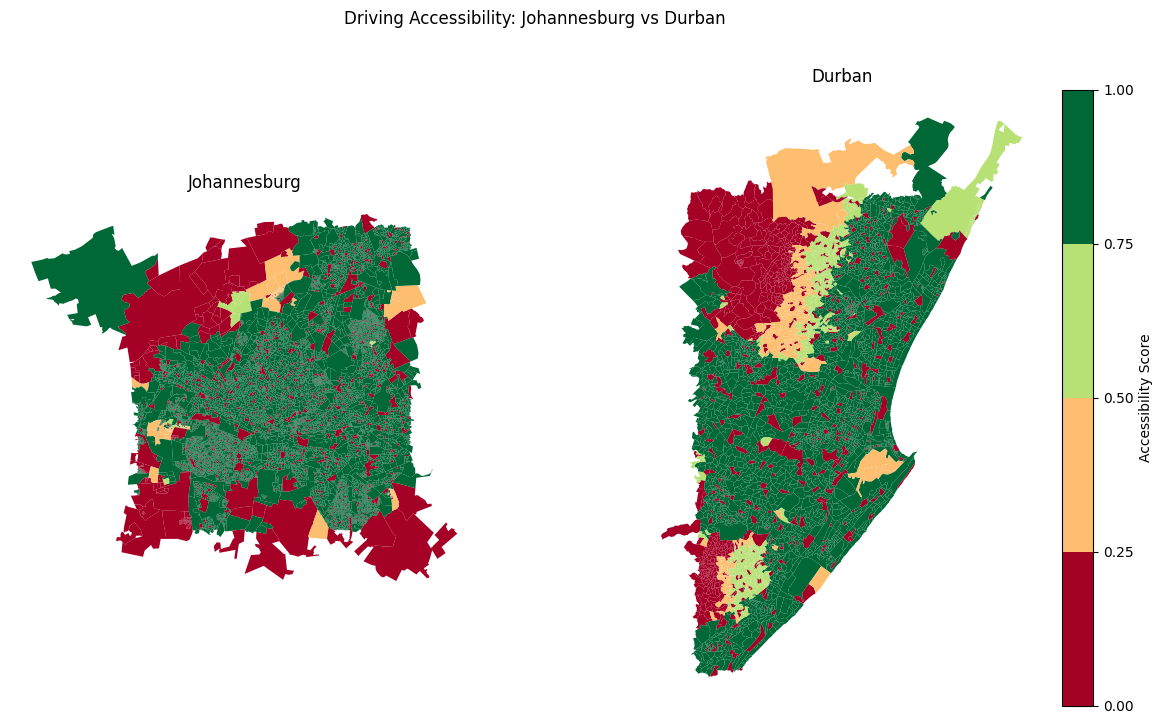

In [220]:
import matplotlib.pyplot as plt
import matplotlib as mpl

bin_edges = [0, 0.25, 0.5, 0.75,1]
cmap = mpl.cm.RdYlGn

norm = mpl.colors.BoundaryNorm(bin_edges, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

cities = {
    "Johannesburg": (27.7, 28.3, -26.4, -25.8),
    "Durban": (30.85, 31.25, -30.05, -29.65)
}

for i, (name, (xmin, xmax, ymin, ymax)) in enumerate(cities.items()):

    gdf = allaccess.cx[xmin:xmax, ymin:ymax]

    gdf.plot(
        column='Ai_drive',
        cmap=cmap,
        norm=norm,          # 🔥 THIS IS THE KEY FIX
        ax=axes[i],
        edgecolor='none'
    )

    # pharm_with_sal.cx[xmin:xmax, ymin:ymax].plot(
    #     ax=axes[i],
    #     color='#3B0C87',
    #     markersize= 1,
    #     zorder=10
    # )

    axes[i].set_title(name)
    axes[i].axis('off')

# shared colorbar (now matches exactly)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Accessibility Score")

plt.suptitle("Driving Accessibility: Johannesburg vs Durban")
plt.savefig("joburgandDurban_driving.png", dpi=150, bbox_inches='tight')

plt.show()

In [224]:
gdf.to_file("../allaccess.csv") 

GeometryError: Could not set geometry for feature at index 0